In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os
import pandas as pd
import argparse
from matplotlib import cm



In [5]:

exp_dir = "/Users/liyingnceas/GitHub/Deep-hurdle-population-model-exp/experiments/default_experiment/version_12"
binary_path = os.path.join(exp_dir, "binary_results.npz")
binary_data = np.load(binary_path)["data"]

In [6]:
binary_data

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 1., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(17331, 700), dtype=float32)

In [29]:
count_predictions = pd.read_csv("multiplied_result.csv")
count_predictions 
# 1) split into GT and Pred
n = binary_data.shape[1] // 2
assert binary_data.shape[1] == 2 * n, "Expected an even number of columns (GT + Pred)."
gt = binary_data[:, :n]
pred = binary_data[:, n:]

# 2) get label (species) names from count_predictions
#    If count_predictions has non-species cols (e.g., longitude/latitude),
#    keep only the first n names or filter as needed.
if isinstance(count_predictions, pd.DataFrame):
    all_cols = list(count_predictions.columns[2:])
else:
    all_cols = list(count_predictions[2:])

label_names = all_cols[:n]
assert len(label_names) == n, "Number of provided feature names must match n."

# 3) build DataFrames with clear names
gt_df   = pd.DataFrame(gt,   columns=label_names).astype(np.float32)
pred_df = pd.DataFrame(pred, columns=label_names).astype(np.float32)
gt_df


,Acadian Flycatcher,Alder Flycatcher,Allen's Hummingbird,American Avocet,American Bittern,American Coot,American Crow,American Golden-Plover,American Goldfinch,American Kestrel,...,Yellow Warbler,Yellow-bellied Flycatcher,Yellow-bellied Sapsucker,Yellow-billed Cuckoo,Yellow-breasted Chat,Yellow-crowned Night Heron,Yellow-headed Blackbird,Yellow-rumped Warbler,Yellow-throated Vireo,Yellow-throated Warbler
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17326,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
17327,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17328,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17329,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# 1) split into GT and Pred
n = binary_data.shape[1] // 2
assert binary_data.shape[1] == 2 * n, "Expected an even number of columns (GT + Pred)."
gt = binary_data[:, :n]
pred = binary_data[:, n:]

# 2) get feature (species) names from count_predictions
#    If count_predictions has non-species cols (e.g., longitude/latitude),
#    keep only the first n names or filter as needed.
if isinstance(count_predictions, pd.DataFrame):
    all_cols = list(count_predictions.columns)
else:
    all_cols = list(count_predictions)

feature_names = all_cols[:n]
assert len(feature_names) == n, "Number of provided feature names must match n."

# 3) build DataFrames with clear names
gt_df   = pd.DataFrame(gt,   columns=feature_names).astype(np.float32)
pred_df = pd.DataFrame(pred, columns=feature_names).astype(np.float32)

# optional: one wide DF with suffixes
wide_df = pd.concat(
    [gt_df.add_suffix("_gt"), pred_df.add_suffix("_pred")],
    axis=1
)

In [30]:
# Load trait data
trait_file="AVONET2_eBird.xlsx"
traits_df = pd.read_excel(trait_file, engine='openpyxl')[['Species2', 'Primary.Lifestyle']]
traits_df = traits_df.dropna(subset=['Species2', 'Primary.Lifestyle'])


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# === Config ===

trait = "Habitat"  # or any other trait column name
trait_file = "AVONET2_eBird.xlsx"
taxonomy_file = "ebird-taxonomy.csv"


# === Step 1: Extract species feature matrix (transpose so species are rows) ===
species_gt = gt_df.copy().T  # shape: [n_species, n_samples]
species_gt.index.name = 'Species'
species_gt = species_gt.fillna(0)

species_pred = pred_df.copy().T  # shape: [n_species, n_samples]
species_pred.index.name = 'Species'
species_pred = species_pred.fillna(0)

# === Step 2: Trait mapping ===
traits_df = pd.read_excel(trait_file, engine='openpyxl')[['Species2', trait]]
traits_df = traits_df.dropna(subset=['Species2', trait])

taxonomy = pd.read_csv(taxonomy_file)
sci_to_common = dict(zip(taxonomy['scientific_name'], taxonomy['common_name']))
traits_df['Species2'] = traits_df['Species2'].map(sci_to_common)

# === Step 3: Map traits to species ===
species_to_group = dict(zip(traits_df['Species2'], traits_df[trait]))
species_gt = species_gt.reset_index()
species_gt['TraitGroup'] = species_gt['Species'].map(species_to_group)
species_gt = species_gt.dropna(subset=['TraitGroup'])
species_pred = species_pred.reset_index()
species_pred['TraitGroup'] = species_pred['Species'].map(species_to_group)
species_pred = species_pred.dropna(subset=['TraitGroup'])



          Habitat     TP     FP     FN      TN  Precision    Recall        F1  \
0          Marine  14996  35726   2884  223690   0.295651  0.838702  0.437188   
1        Woodland  30513  69862  11004  373889   0.303990  0.734952  0.430088   
2  Human Modified  18340  55843   7366  247740   0.247226  0.713452  0.367208   
3       Shrubland  26842  88493  10103  498478   0.232731  0.726539  0.352535   
4        Riverine   1533   8262    518   41680   0.156508  0.747440  0.258822   

   Accuracy  True Positives (count)  Pred Positives (count)  
0  0.860763                   17880                   50722  
1  0.833358                   41517                  100375  
2  0.808044                   25706                   74183  
3  0.841972                   36945                  115335  
4  0.831131                    2051                    9795  


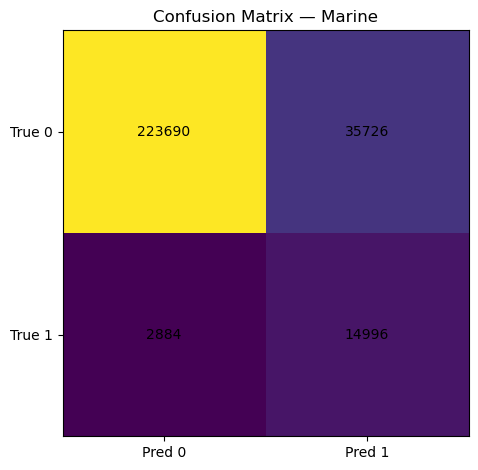

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----- Prep: align by species and keep only sample columns -----
sg = species_gt.set_index('Species')
sp = species_pred.set_index('Species')

# group labels per species
groups = sg['TraitGroup']

# keep only sample columns (everything except TraitGroup)
sg_X = sg.drop(columns=['TraitGroup'])
sp_X = sp.drop(columns=['TraitGroup'])

# ensure same species and same sample columns in same order
common_species = sg_X.index.intersection(sp_X.index)
common_samples = sg_X.columns.intersection(sp_X.columns)
sg_X = sg_X.loc[common_species, common_samples]
sp_X = sp_X.loc[common_species, common_samples]
groups = groups.loc[common_species]

# ----- Helper: confusion counts and metrics -----
def confusion_counts(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tn, fp, fn, tp

def prec_rec_f1_acc(tn, fp, fn, tp):
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = (2 * prec * rec / (prec + rec)) if (prec + rec) > 0 else 0.0
    acc  = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else np.nan
    return prec, rec, f1, acc

# ----- Main: compute confusion per habitat -----
threshold = 0.5  # change if your predictions are already 0/1
results = []
cm_by_habitat = {}

for hab, idx in groups.groupby(groups).groups.items():
    y_true = sg_X.loc[idx].to_numpy().ravel()
    y_pred = sp_X.loc[idx].to_numpy().ravel()

    # drop NaNs
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    # binarize if needed
    y_true = (y_true >= threshold).astype(int)
    y_pred = (y_pred >= threshold).astype(int)

    tn, fp, fn, tp = confusion_counts(y_true, y_pred)
    prec, rec, f1, acc = prec_rec_f1_acc(tn, fp, fn, tp)

    results.append({
        "Habitat": hab,
        "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
        "Precision": prec, "Recall": rec, "F1": f1, "Accuracy": acc,
        "True Positives (count)": int((y_true == 1).sum()),
        "Pred Positives (count)": int((y_pred == 1).sum())
    })
    cm_by_habitat[hab] = np.array([[tn, fp],
                                   [fn, tp]], dtype=int)

cm_summary = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)
print(cm_summary.head())

# ----- Example plot for one habitat -----
example_habitat = cm_summary.iloc[0]["Habitat"]  # top F1 habitat (or set manually)
cm = cm_by_habitat[example_habitat]

fig, ax = plt.subplots()
im = ax.imshow(cm)
ax.set_xticks([0,1]); ax.set_xticklabels(['Pred 0','Pred 1'])
ax.set_yticks([0,1]); ax.set_yticklabels(['True 0','True 1'])
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha='center', va='center')
ax.set_title(f'Confusion Matrix — {example_habitat}')
plt.tight_layout()
plt.show()


In [33]:
species_gt

,Species,0,1,2,3,4,5,6,7,8,...,17322,17323,17324,17325,17326,17327,17328,17329,17330,TraitGroup
0,Acadian Flycatcher,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Forest
1,Alder Flycatcher,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Shrubland
2,Allen's Hummingbird,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Shrubland
3,American Avocet,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Wetland
4,American Bittern,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Wetland
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,Yellow-crowned Night Heron,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Coastal
346,Yellow-headed Blackbird,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Wetland
347,Yellow-rumped Warbler,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,Forest
348,Yellow-throated Vireo,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,Forest


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def confusion_by_group(species_gt, species_pred, group_col="TraitGroup", threshold=0.5):
    """
    Compute per-group confusion matrices by flattening all species x samples
    that belong to each group (micro-averaging within group).

    Parameters
    ----------
    species_gt : pd.DataFrame
        Rows: species, Columns: samples, plus ['Species', group_col]
    species_pred : pd.DataFrame
        Same shape/structure as species_gt
    group_col : str
        Column name that holds the group label (e.g., 'TraitGroup' == Habitat)
    threshold : float
        Threshold to binarize GT and predictions if they are probabilities

    Returns
    -------
    cm_summary : pd.DataFrame
        Per-group counts and metrics (TN, FP, FN, TP, Precision, Recall, F1, Acc, etc.)
    cm_dict : dict[str, np.ndarray]
        {group: 2x2 numpy array [[TN, FP],[FN, TP]]}
    """
    # --- align by species and shared sample columns ---
    sg = species_gt.set_index('Species')
    sp = species_pred.set_index('Species')

    # group labels from GT table
    groups = sg[group_col]

    # only sample columns (drop the group col)
    sg_X = sg.drop(columns=[group_col])
    sp_X = sp.drop(columns=[group_col])

    # intersect on species and sample columns
    common_species = sg_X.index.intersection(sp_X.index)
    common_cols = sg_X.columns.intersection(sp_X.columns)
    sg_X = sg_X.loc[common_species, common_cols]
    sp_X = sp_X.loc[common_species, common_cols]
    groups = groups.loc[common_species]

    # helpers
    def counts(y_true, y_pred):
        tp = np.sum((y_true == 1) & (y_pred == 1))
        tn = np.sum((y_true == 0) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        return tn, fp, fn, tp

    def metrics(tn, fp, fn, tp):
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec  = tp / (tp + fn) if (tp + fn) else 0.0
        f1   = (2*prec*rec/(prec+rec)) if (prec + rec) else 0.0
        acc  = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) else np.nan
        tnr  = tn / (tn + fp) if (tn + fp) else np.nan  # specificity
        fpr  = fp / (fp + tn) if (fp + tn) else np.nan
        fnr  = fn / (fn + tp) if (fn + tp) else np.nan
        return prec, rec, f1, acc, tnr, fpr, fnr

    cm_rows = []
    cm_dict = {}

    for grp, idx in groups.groupby(groups).groups.items():
        y_true = sg_X.loc[idx].to_numpy().ravel()
        y_pred = sp_X.loc[idx].to_numpy().ravel()

        # drop NaNs
        mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
        y_true = y_true[mask]
        y_pred = y_pred[mask]

        # binarize (set threshold=0 if data already 0/1)
        y_true = (y_true >= threshold).astype(int)
        y_pred = (y_pred >= threshold).astype(int)

        tn, fp, fn, tp = counts(y_true, y_pred)
        prec, rec, f1, acc, tnr, fpr, fnr = metrics(tn, fp, fn, tp)

        cm_dict[grp] = np.array([[tn, fp],
                                 [fn, tp]], dtype=int)
        cm_rows.append({
            "Habitat": grp,
            "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
            "Support_true_positives": int((y_true == 1).sum()),
            "Support_samples": int(y_true.size),
            "Precision": prec, "Recall": rec, "F1": f1, "Accuracy": acc,
            "Specificity": tnr, "FPR": fpr, "FNR": fnr
        })

    cm_summary = pd.DataFrame(cm_rows).sort_values("F1", ascending=False).reset_index(drop=True)
    return cm_summary, cm_dict

# ---- run it ----
cm_summary, cm_dict = confusion_by_group(species_gt, species_pred, group_col="TraitGroup", threshold=0.5)
cm_summary


,Habitat,TN,FP,FN,TP,Support_true_positives,Support_samples,Precision,Recall,F1,Accuracy,Specificity,FPR,FNR
0,Marine,223690,35726,2884,14996,17880,277296,0.295651,0.838702,0.437188,0.860763,0.862283,0.137717,0.161298
1,Woodland,373889,69862,11004,30513,41517,485268,0.303990,0.734952,0.430088,0.833358,0.842565,0.157435,0.265048
2,Human Modified,247740,55843,7366,18340,25706,329289,0.247226,0.713452,0.367208,0.808044,0.816054,0.183946,0.286548
3,Shrubland,498478,88493,10103,26842,36945,623916,0.232731,0.726539,0.352535,0.841972,0.849238,0.150762,0.273461
4,Riverine,41680,8262,518,1533,2051,51993,0.156508,0.747440,0.258822,0.831131,0.834568,0.165432,0.252560
5,Coastal,256704,45503,1981,7770,9751,311958,0.145852,0.796841,0.246573,0.847787,0.849431,0.150569,0.203159
6,Forest,1447011,221813,13302,33643,46945,1715769,0.131698,0.716647,0.222506,0.862968,0.867084,0.132916,0.283353
7,Wetland,1387399,231850,11696,32831,44527,1663776,0.124040,0.737328,0.212355,0.853619,0.856816,0.143184,0.262672
8,Grassland,518281,48464,1732,3446,5178,571923,0.066384,0.665508,0.120726,0.912233,0.914487,0.085513,0.334492


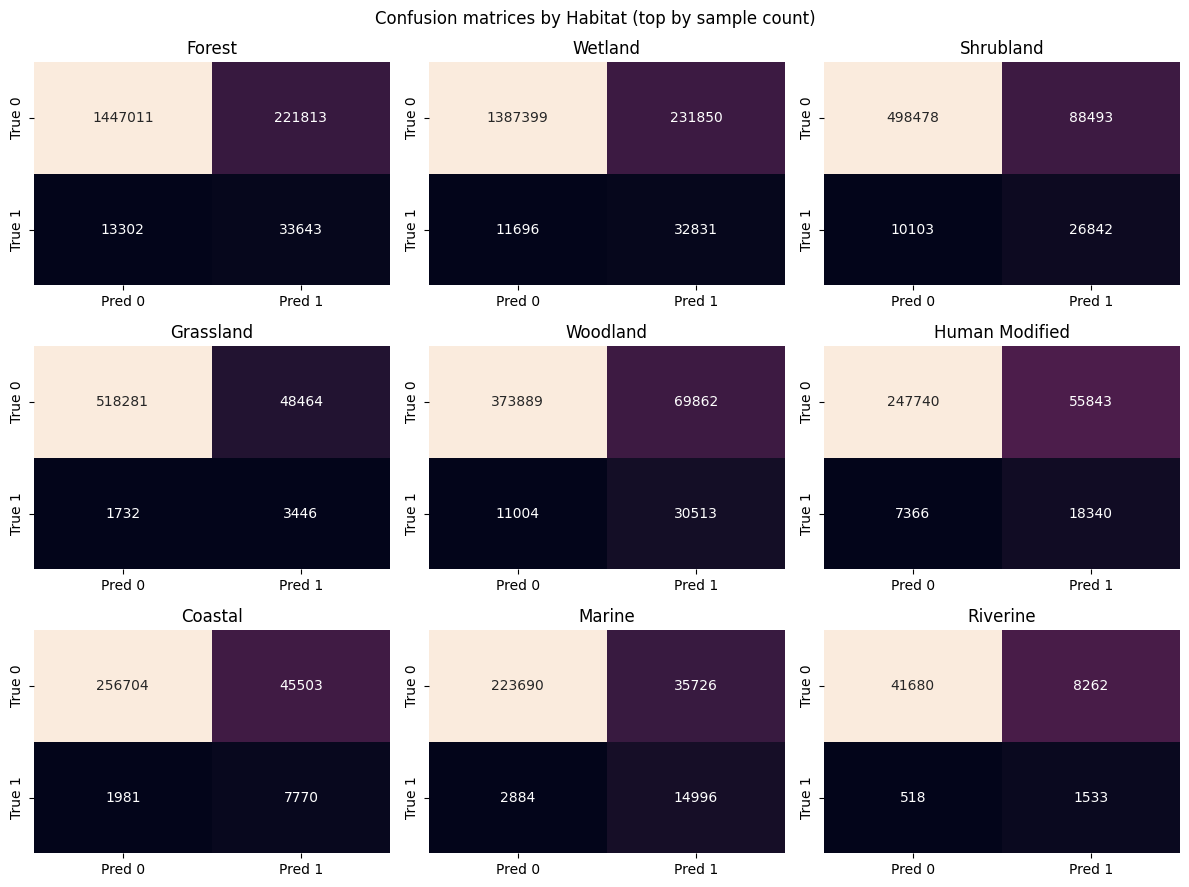

In [29]:
import math
import seaborn as sns

top = cm_summary.sort_values("Support_samples", ascending=False).head(9)["Habitat"].tolist()
n = len(top)
cols = 3
rows = math.ceil(n/cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))
axes = np.array(axes).reshape(rows, cols)

for ax, hab in zip(axes.ravel(), top):
    cm = cm_dict[hab]
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, ax=ax,
                xticklabels=["Pred 0","Pred 1"],
                yticklabels=["True 0","True 1"])
    ax.set_title(hab)

# hide unused axes
for ax in axes.ravel()[n:]:
    ax.axis("off")

fig.suptitle("Confusion matrices by Habitat (top by sample count)")
plt.tight_layout()
plt.show()


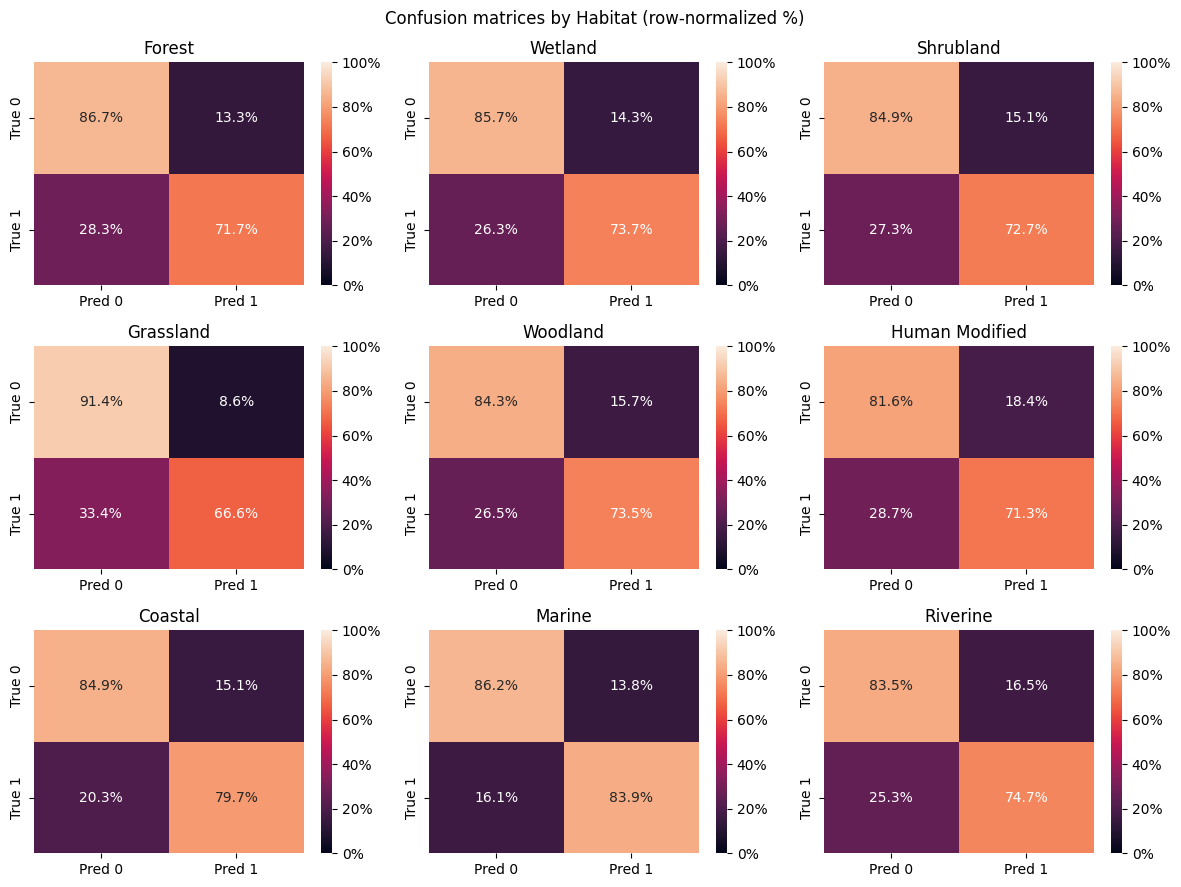

In [30]:
import numpy as np
from matplotlib.ticker import PercentFormatter

top = cm_summary.sort_values("Support_samples", ascending=False).head(9)["Habitat"].tolist()
n = len(top)
cols = 3
rows = math.ceil(n/cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))
axes = np.array(axes).reshape(rows, cols)

for ax, hab in zip(axes.ravel(), top):
    cm = cm_dict[hab].astype(float)                     # [[TN, FP],[FN, TP]]

    # --- ROW normalization (True 0 row, True 1 row) ---
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1                         # avoid divide-by-zero
    cm_pct = cm / row_sums                               # values in [0,1]

    # Pretty percent annotations like "83.3%"
    annot = np.array([[f"{v:.1%}" for v in row] for row in cm_pct])

    sns.heatmap(
        cm_pct, annot=annot, fmt="", cbar=True, ax=ax,
        xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"],
        vmin=0, vmax=1, cbar_kws={"format": PercentFormatter(xmax=1)}
    )
    ax.set_title(hab)

# hide unused axes
for ax in axes.ravel()[n:]:
    ax.axis("off")

fig.suptitle("Confusion matrices by Habitat (row-normalized %)")
plt.tight_layout()
plt.show()


In [32]:
import os

out_pdf = "confusion_matrices_by_habitat_row_norm.pdf"

# after plt.tight_layout()
fig.savefig(out_pdf, format="pdf", dpi=300, bbox_inches="tight")
plt.close(fig)
print(f"Saved: {out_pdf}")


Saved: confusion_matrices_by_habitat_row_norm.pdf


Saved grid PNG: figs/confusion_by_habitat_row_norm_orgreen1.png
Saved grid PDF: figs/confusion_by_habitat_row_norm_orgreen1.pdf


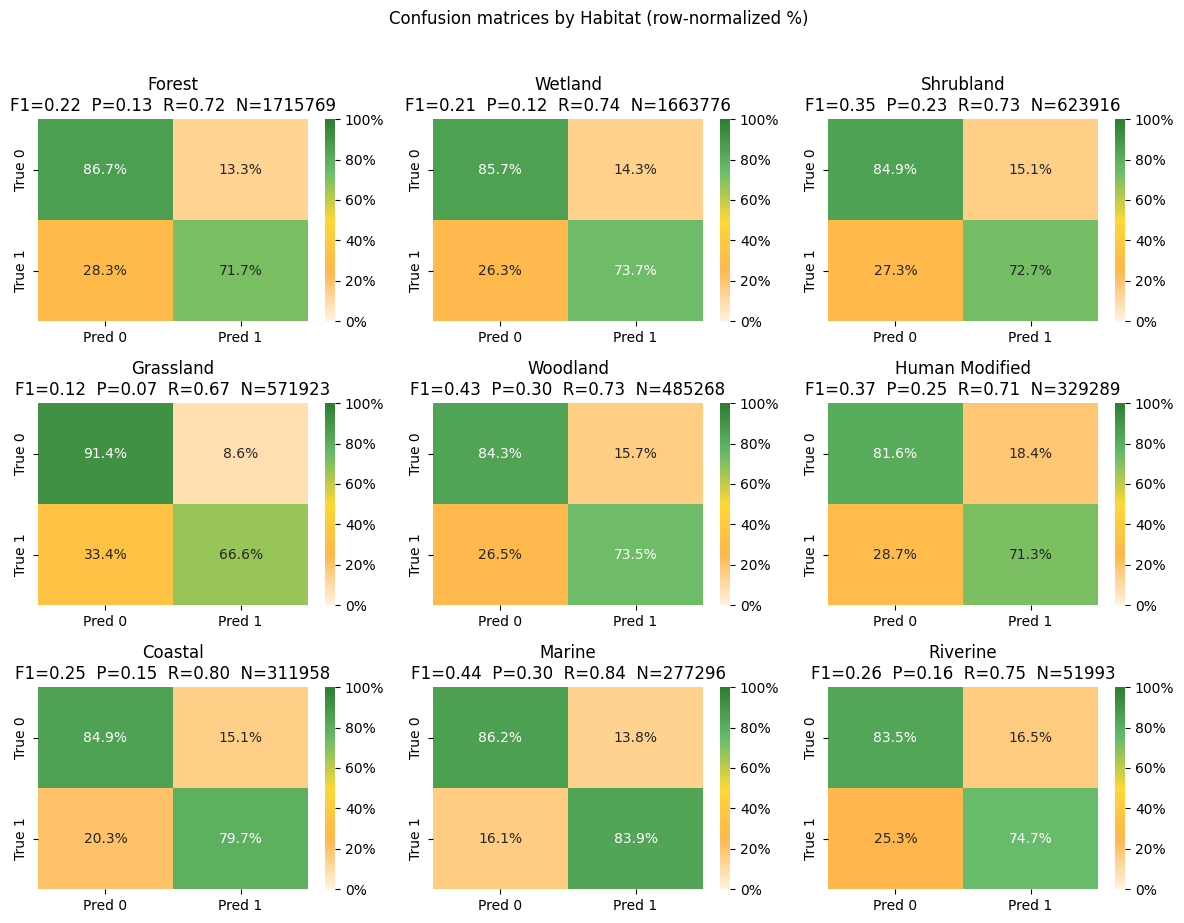

In [ ]:
# === Strong-contrast confusion-matrix heatmaps (orange -> dark red) ===
# Prereqs: cm_summary (DataFrame) and cm_dict ({habitat: 2x2 numpy array})
# built earlier via your confusion-by-habitat code.

import os, math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter
from matplotlib.backends.backend_pdf import PdfPages
# --- Custom high-contrast colormap: different color options pick one you like ---

red_to_blue = LinearSegmentedColormap.from_list(
    "red_to_blue",
    [
        "#FDE0DD",  # very light red
        "#FDA0A1",  # light red
        "#FB6A4A",  # medium red
        "#9ECAE1",  # light blue
        "#4292C6",  # medium blue
        "#08519C",  # dark blue
    ]
)
green_to_orange = LinearSegmentedColormap.from_list(
    "green_to_orange",
    [
        "#E8F5E9",  # very light green
        "#A5D6A7",  # light/medium green
        "#66BB6A",  # medium green
        "#FDD835",  # warm yellow
        "#FB8C00",  # orange
        "#E65100",  # dark orange
    ]
)
red_to_green = LinearSegmentedColormap.from_list(
    "red_to_green",
    [
        "#FDE0DD",  # very light red (low)
        "#FC9272",  # salmon
        "#FEE08B",  # warm yellow mid
        "#78C679",  # medium green
        "#31A354",  # strong green
        "#0B7D2A",  # dark green (high)
    ]
)
yellow_to_darkgreen = LinearSegmentedColormap.from_list(
    "yellow_to_darkgreen",
    ["#FFFACD", "#F1F7A1", "#A1D76A", "#31A354"]  # pale yellow -> deep green
)
# --- Custom high-contrast colormap: orange -> dark red ---
orange_to_darkred = LinearSegmentedColormap.from_list(
    "orange_to_darkred",
    ["#FFA500", "#FF8C00", "#D62728", "#8B0000"]  # orange → dark red
)
orange_to_green = LinearSegmentedColormap.from_list(
    "orange_to_green",
    [
        "#FFF3E0",  # very light orange (low)
        "#FFB74D",  # orange
        "#FDD835",  # warm yellow mid
        "#66BB6A",  # medium green
        "#2E7D32",  # dark green (high)
    ]
)
# --- Select habitats to plot (top 9 by sample count) ---
top = cm_summary.sort_values("Support_samples", ascending=False).head(12)["Habitat"].tolist()
n = len(top)
cols = 3
rows = math.ceil(n / cols)

# --- Make figure grid ---
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
axes = np.atleast_2d(axes).reshape(rows, cols)

for ax, hab in zip(axes.ravel(), top):
    cm = cm_dict[hab].astype(float)  # [[TN, FP],[FN, TP]]

    # Row-normalize: each true class row sums to 1.0
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1     # avoid divide-by-zero if a row is empty
    cm_pct = cm / row_sums

    # Pretty percentage annotations
    annot = np.array([[f"{v:.1%}" for v in row] for row in cm_pct])

    sns.heatmap(
        cm_pct, annot=annot, fmt="", cbar=True, ax=ax,
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"],
        vmin=0, vmax=1,
        cmap=orange_to_green,
        cbar_kws={"format": PercentFormatter(xmax=1)}
    )
    # Optional: include metrics in the title
    r = cm_summary.loc[cm_summary["Habitat"] == hab].iloc[0]
    ax.set_title(f"{hab}\nF1={r['F1']:.2f}  P={r['Precision']:.2f}  R={r['Recall']:.2f}  N={int(r['Support_samples'])}")

# Hide any unused axes
for ax in axes.ravel()[n:]:
    ax.axis("off")

fig.suptitle("Confusion matrices by Habitat (row-normalized %)", y=1.02)
plt.tight_layout()

# --- Optional saves ---
os.makedirs("figs", exist_ok=True)
grid_png = "figs/confusion_by_habitat_row_norm_orgreen1.png"
grid_pdf = "figs/confusion_by_habitat_row_norm_orgreen1.pdf"
fig.savefig(grid_png, dpi=300, bbox_inches="tight")
fig.savefig(grid_pdf, dpi=300, bbox_inches="tight")
print(f"Saved grid PNG: {grid_png}")
print(f"Saved grid PDF: {grid_pdf}")

# --- Optional: multi-page PDF (one habitat per page)


In [14]:
exp_dir = "/Users/liyingnceas/GitHub/Deep-hurdle-population-model-exp/lightning_logs/historical"

In [15]:
label_label_embedpath = os.path.join(exp_dir, "label_label_emb_regressor.csv")
label_label_embed = pd.read_csv(label_label_embedpath)
label_label_embed

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,0.019482,-0.009918,-0.008635,-0.049887,-0.057232,0.000257,-0.004984,-0.047060,-0.027219,-0.079788,...,0.058129,-0.018868,-0.055930,0.030200,-0.048974,-0.063232,-0.020444,-0.022009,0.002449,0.049941
1,0.024496,-0.048166,-0.044374,-0.030337,-0.061932,-0.062117,0.024561,-0.007316,-0.064174,-0.030392,...,-0.006001,-0.029083,-0.003578,-0.073699,-0.031910,0.000116,-0.029325,0.031773,0.022779,-0.033839
2,-0.058691,-0.032596,-0.013400,0.025559,0.014132,0.036337,-0.018823,0.016980,-0.009585,-0.021006,...,0.000038,0.015987,0.002461,0.021912,-0.068183,-0.023529,-0.052564,-0.051287,0.014361,-0.005077
3,-0.032421,0.009040,-0.001239,-0.023820,0.026403,-0.023457,-0.043227,-0.070839,-0.010512,-0.082852,...,0.000713,-0.029640,0.015562,-0.014702,-0.022549,-0.040569,0.044837,0.050870,-0.058503,-0.036346
4,0.006974,-0.022111,-0.006163,-0.070298,-0.075279,0.037842,0.037206,0.019995,-0.000242,-0.000763,...,0.009598,-0.051814,-0.048016,-0.029437,-0.066407,-0.002340,0.033753,0.028576,-0.043609,0.003849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,-0.042332,-0.025306,-0.019416,0.018052,-0.034778,-0.040641,-0.027850,-0.017781,0.014266,0.001860,...,0.048542,-0.057636,-0.043837,-0.047173,-0.041574,0.023988,0.019541,0.051674,-0.071739,-0.027275
696,0.004802,0.004149,-0.032123,-0.068231,-0.065917,0.035329,0.009831,-0.025822,0.036149,-0.025638,...,0.029206,0.033118,-0.000648,0.026381,-0.001189,-0.050316,0.034650,0.049087,-0.051960,0.044537
697,0.038483,0.054070,-0.004319,0.061786,0.030224,-0.025051,0.034254,0.004128,-0.027901,-0.028346,...,0.022101,-0.002679,0.003056,0.045585,-0.004407,-0.009864,-0.001305,0.016079,-0.025677,0.001003
698,-0.042825,0.002606,-0.083702,-0.067990,0.010440,0.046073,0.020140,-0.053635,0.047616,0.008395,...,-0.025112,-0.002453,-0.077217,0.033570,-0.014910,-0.027314,-0.005706,-0.036565,0.019462,0.025239


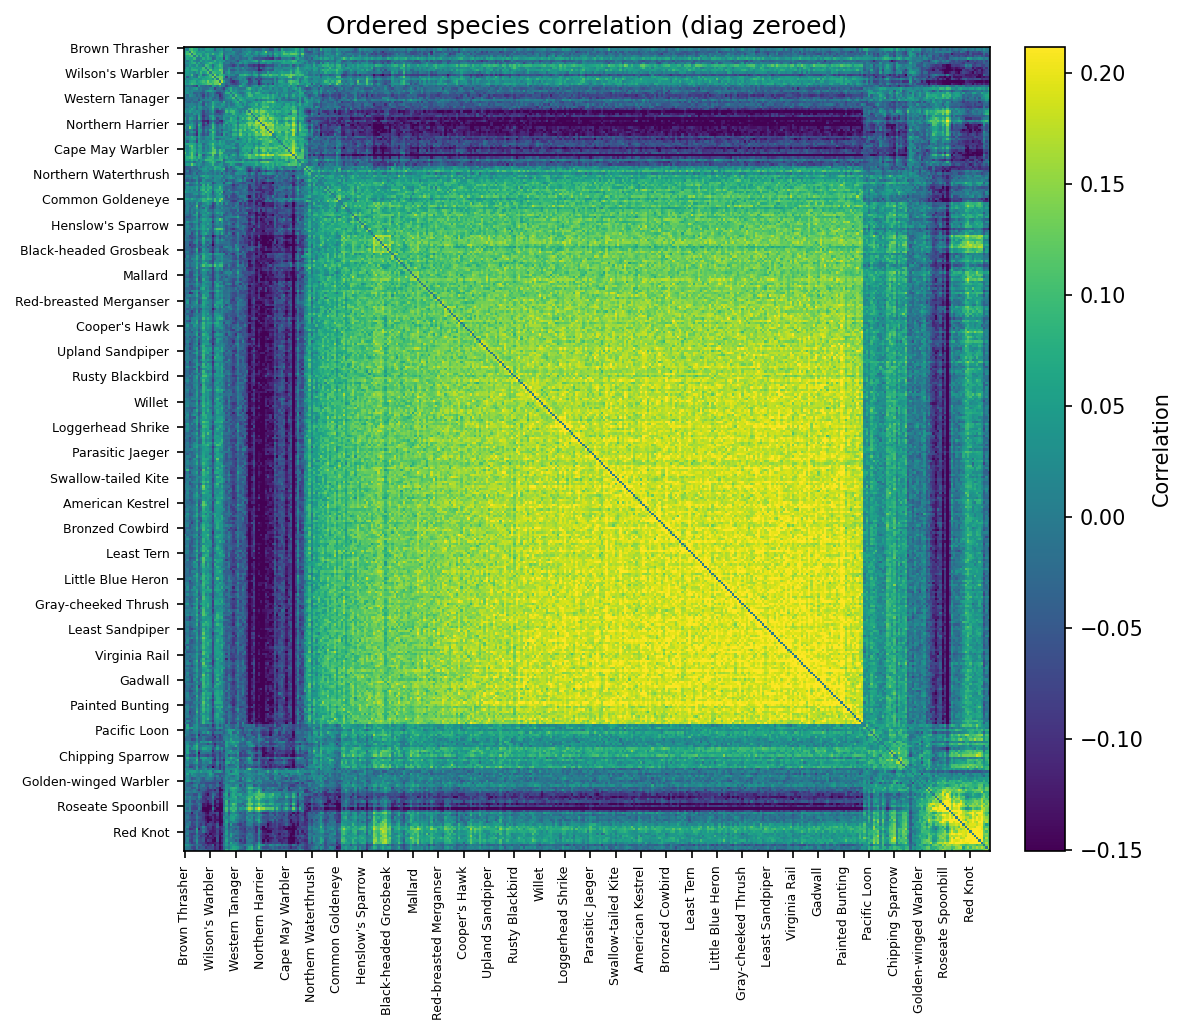

In [55]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# --- names from your ground-truth df ---
species_names = list(gt_df.columns.astype(str))
S = len(species_names)

# --- load & clean embedding ---
label_label_embedpath = os.path.join(exp_dir, "label_label_emb_regressor.csv")
E_raw = pd.read_csv(label_label_embedpath)

# keep only numeric columns (drop things like 'Unnamed: 0')
E = E_raw.select_dtypes(include=[np.number]).copy()

# sanity checks
if E.shape[0] < S:
    raise ValueError(f"Embedding has only {E.shape[0]} rows but you have {S} species names.")
# Trim to your 350 species (NOTE: this assumes row order matches your 350 species)
E = E.iloc[:S].copy()
E.index = species_names  # label rows by your species names

# --- build row-wise correlation (species × species) ---
X = E.to_numpy(dtype=float)
X = X - X.mean(axis=1, keepdims=True)     # center per species
R = np.corrcoef(X)                        # row-wise correlation
np.fill_diagonal(R, 1.0)

# --- cluster order ---
def cluster_order(R, method="average"):
    M = np.clip(R, -1, 1)
    np.fill_diagonal(M, 1.0)
    D = 1.0 - M
    np.fill_diagonal(D, 0.0)
    Z = linkage(squareform(D, checks=False), method=method)
    return leaves_list(Z)

order = cluster_order(R)
R_ord = R[np.ix_(order, order)].copy()
names_ord = [species_names[i] for i in order]

# zero diagonal for display only
np.fill_diagonal(R_ord, 0.0)

# tight color limits so small structure pops
off = R_ord[~np.eye(S, dtype=bool)]
lo, hi = np.quantile(off, [0.02, 0.98])
if np.isclose(lo, hi):
    pad = 1e-3 if hi == 0 else 0.05 * abs(hi)
    lo, hi = lo - pad, hi + pad

# --- plot ---
fig, ax = plt.subplots(figsize=(8,7), dpi=150)
im = ax.imshow(R_ord, vmin=float(lo), vmax=float(hi), interpolation="nearest", aspect="auto")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cbar.set_label("Correlation")
ax.set_title("Ordered species correlation (diag zeroed)")

step = max(1, S // 30)
ax.set_xticks(range(0, S, step)); ax.set_yticks(range(0, S, step))
ax.set_xticklabels([names_ord[i] for i in range(0, S, step)], rotation=90, fontsize=6)
ax.set_yticklabels([names_ord[i] for i in range(0, S, step)], fontsize=6)
plt.tight_layout()
plt.show()



In [56]:
# --- optional: top pairs for inspection ---
def top_pairs(M, names, k=20):
    A = M.copy(); np.fill_diagonal(A, 0.0)
    iu = np.triu_indices_from(A, k=1)
    vals = A[iu]
    idx = np.argsort(np.abs(vals))[::-1][:k]
    return [(names[i], names[j], float(vals[idx_pos]))
            for idx_pos, (i, j) in zip(idx, zip(iu[0][idx], iu[1][idx]))]

print("Top 20 strongest |corr| pairs:")
for a,b,v in top_pairs(R[np.ix_(order, order)], names_ord, k=20):
    print(f"{a} — {b}: {v:+.3f}")


Top 20 strongest |corr| pairs:
Red-eyed Vireo — Worm-eating Warbler: +0.273
Carolina Wren — Painted Bunting: +0.266
Chuck-will's-widow — Worm-eating Warbler: +0.260
Chuck-will's-widow — Glaucous Gull: +0.259
King Rail — Rufous Hummingbird: +0.259
Field Sparrow — Worm-eating Warbler: +0.257
Belted Kingfisher — Least Flycatcher: +0.257
Red-headed Woodpecker — Worm-eating Warbler: +0.255
Carolina Chickadee — Sanderling: +0.255
Least Sandpiper — Long-tailed Duck: +0.255
latitude — Chuck-will's-widow: +0.255
Brown Pelican — Carolina Wren: +0.253
Black-whiskered Vireo — Gray Kingbird: +0.252
White-winged Scoter — Sanderling: +0.251
Couch's Kingbird — Worm-eating Warbler: +0.251
White-winged Scoter — Belted Kingfisher: +0.250
Wild Turkey — Carolina Wren: +0.250
Ruddy Turnstone — Carolina Wren: +0.250
Brown Pelican — Golden-crowned Kinglet: +0.250
Gull-billed Tern — South Polar Skua: +0.249


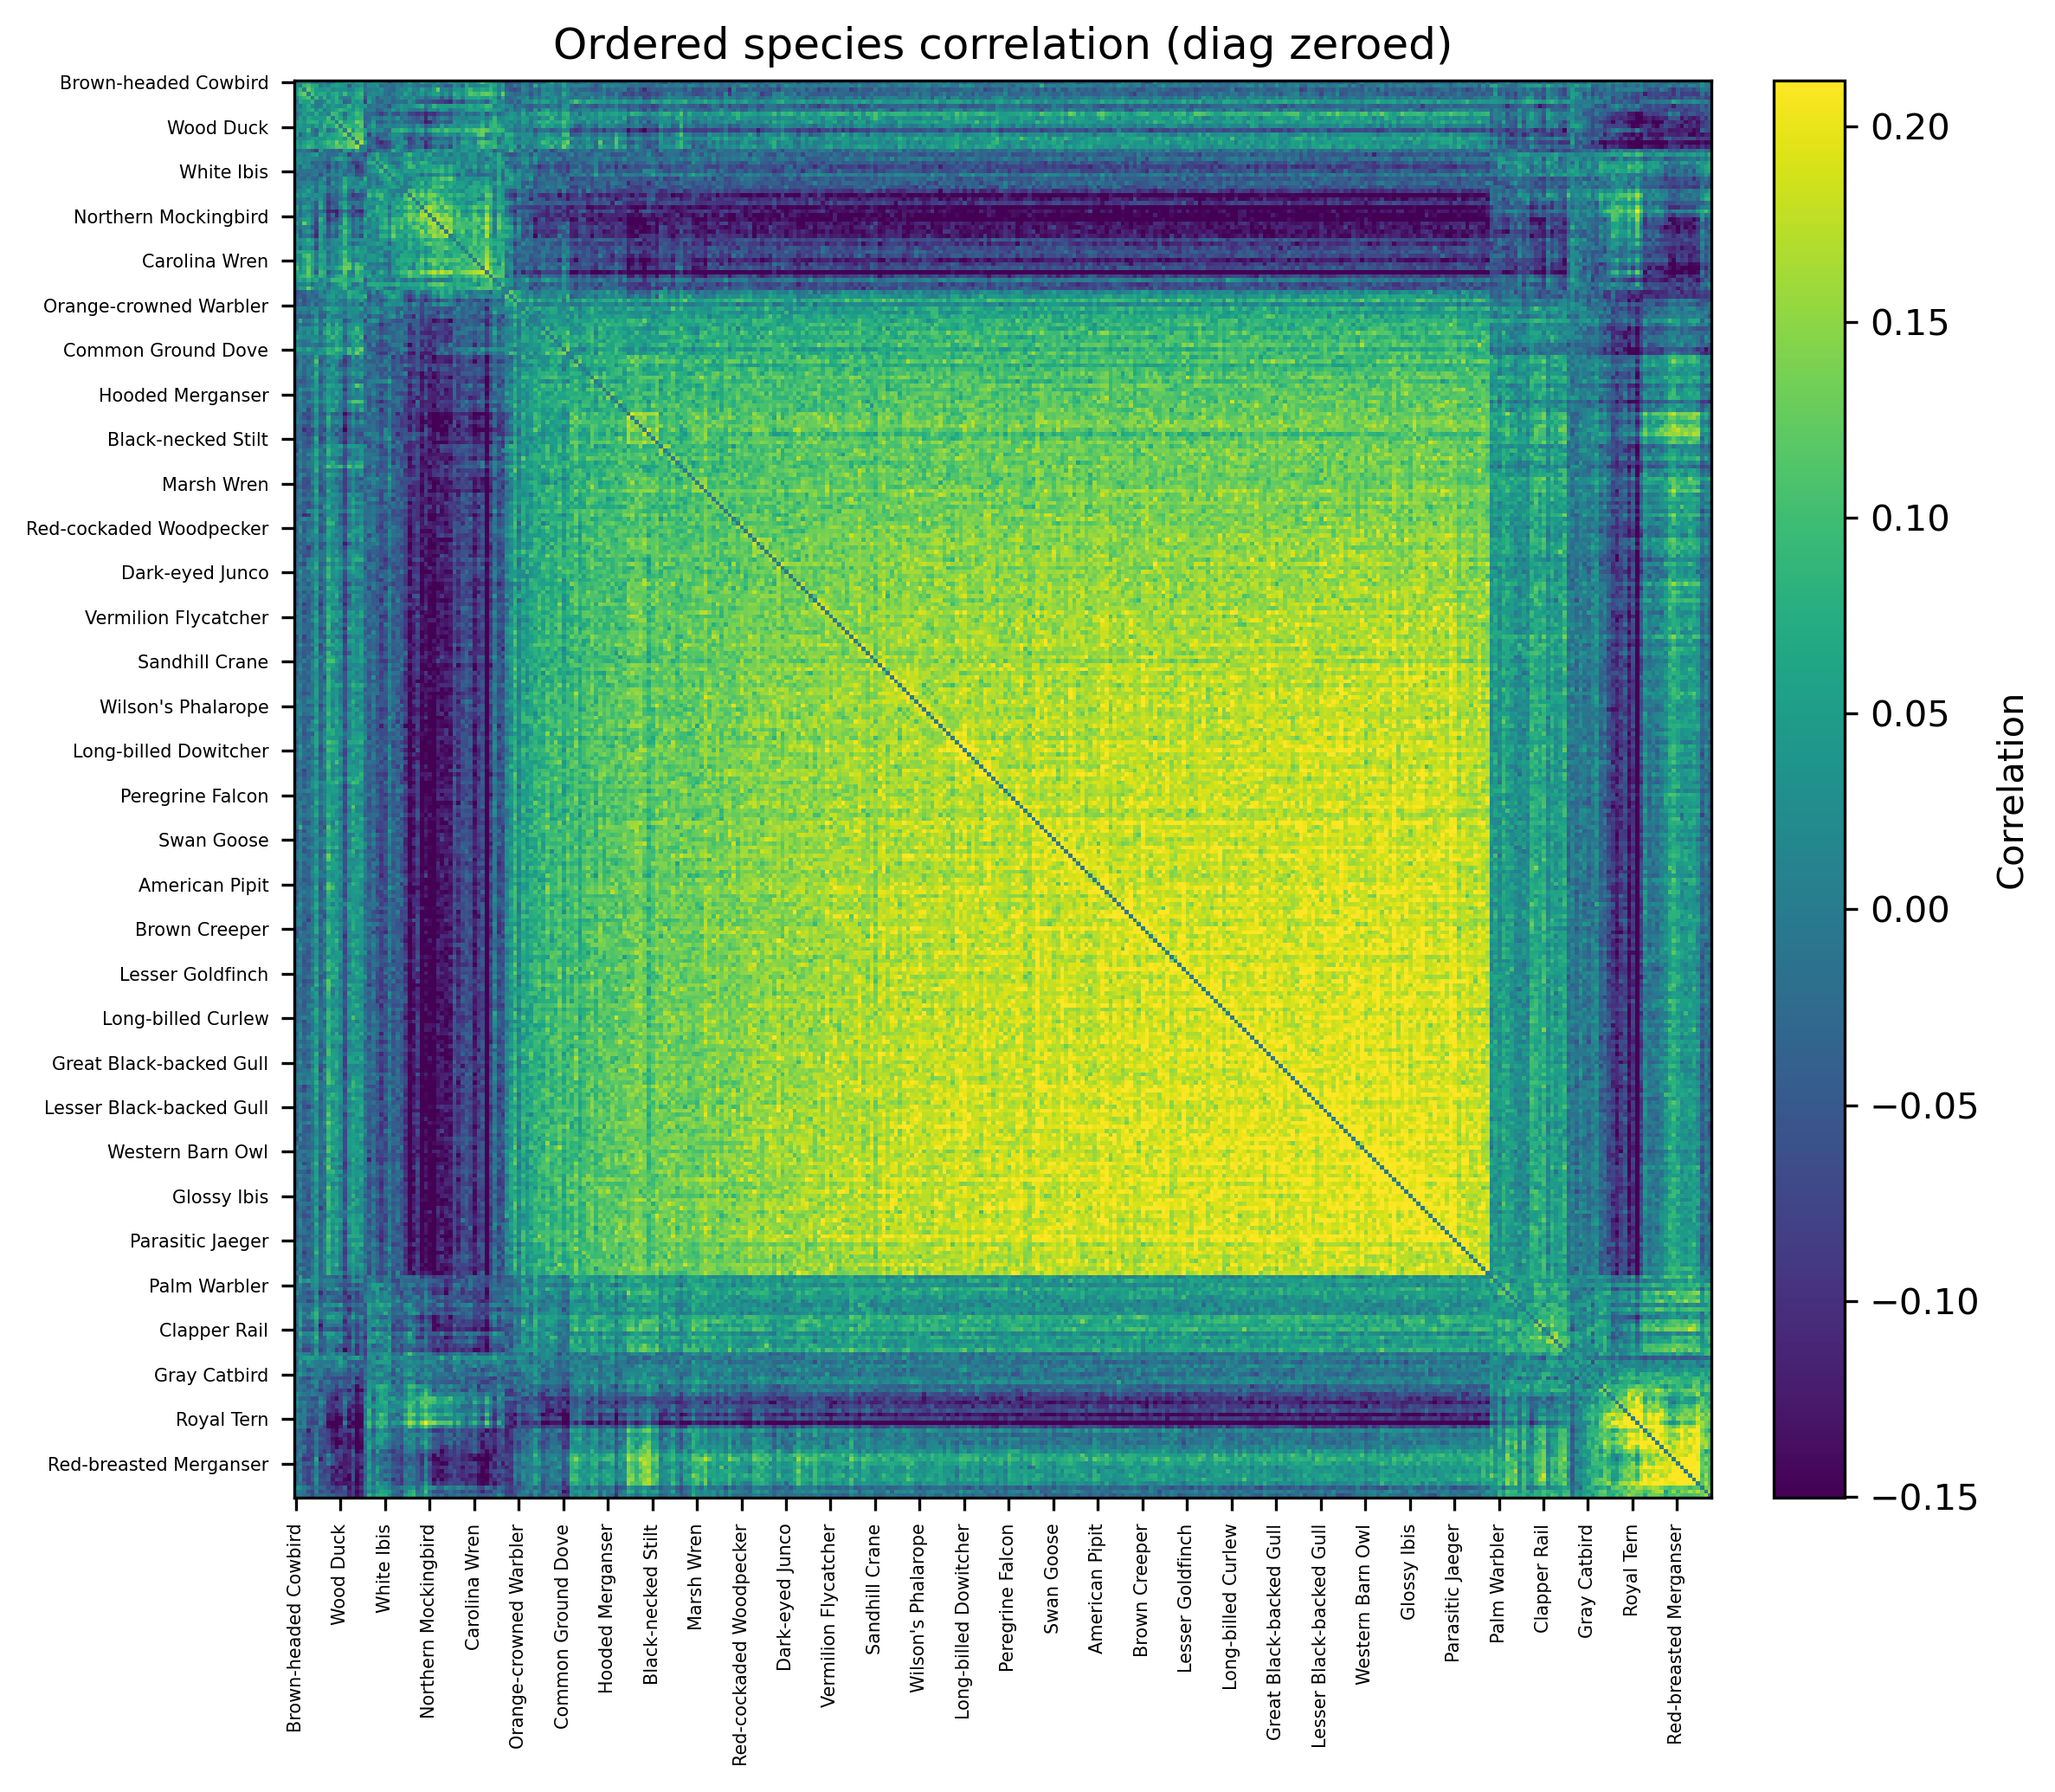

In [26]:
# ... after you compute E (rows=species, cols=embedding dims) and species_names ...

import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# Build row-wise correlation (species × species)
X = E.to_numpy(dtype=float)
X = X - X.mean(axis=1, keepdims=True)     # center per species
R = np.corrcoef(X)                        # row-wise Pearson correlation
np.fill_diagonal(R, 1.0)

# Cluster order (average linkage on 1 - r)
def cluster_order(R, method="average"):
    M = np.clip(R, -1, 1)
    np.fill_diagonal(M, 1.0)
    D = 1.0 - M
    np.fill_diagonal(D, 0.0)
    Z = linkage(squareform(D, checks=False), method=method)
    return leaves_list(Z)

order = cluster_order(R)
R_ord = R[np.ix_(order, order)].copy()
names_ord = [E.index[i] for i in order]

# Zero diagonal for display only
np.fill_diagonal(R_ord, 0.0)

# Tight color limits so subtle structure pops
off = R_ord[~np.eye(R_ord.shape[0], dtype=bool)]
lo, hi = np.quantile(off, [0.02, 0.98])
if np.isclose(lo, hi):
    pad = 1e-3 if hi == 0 else 0.05 * abs(hi)
    lo, hi = lo - pad, hi + pad

# Plot
fig, ax = plt.subplots(figsize=(8, 7), dpi=300)
im = ax.imshow(R_ord, vmin=float(lo), vmax=float(hi), interpolation="nearest", aspect="auto")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cbar.set_label("Correlation")
ax.set_title("Ordered species correlation (diag zeroed)")

S = R_ord.shape[0]
step = max(1, S // 30)
ax.set_xticks(range(0, S, step)); ax.set_yticks(range(0, S, step))
ax.set_xticklabels([names_ord[i] for i in range(0, S, step)], rotation=90, fontsize=5)
ax.set_yticklabels([names_ord[i] for i in range(0, S, step)], fontsize=5)

plt.tight_layout()

# ✅ Save to PDF (and optional PNG)
out_dir = exp_dir  # or any folder you like
pdf_path = os.path.join(out_dir, "species_interactions_ordered.pdf")
png_path = os.path.join(out_dir, "species_interactions_ordered.png")

fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")

plt.show()

# (Optional) Save the ordered matrix and order for reproducibility
pd.DataFrame(R[np.ix_(order, order)], index=names_ord, columns=names_ord)\
  .to_csv(os.path.join(out_dir, "species_interactions_ordered_corr.csv"))
pd.Series(names_ord, name="species_order")\
  .to_csv(os.path.join(out_dir, "species_order.txt"), index=False)


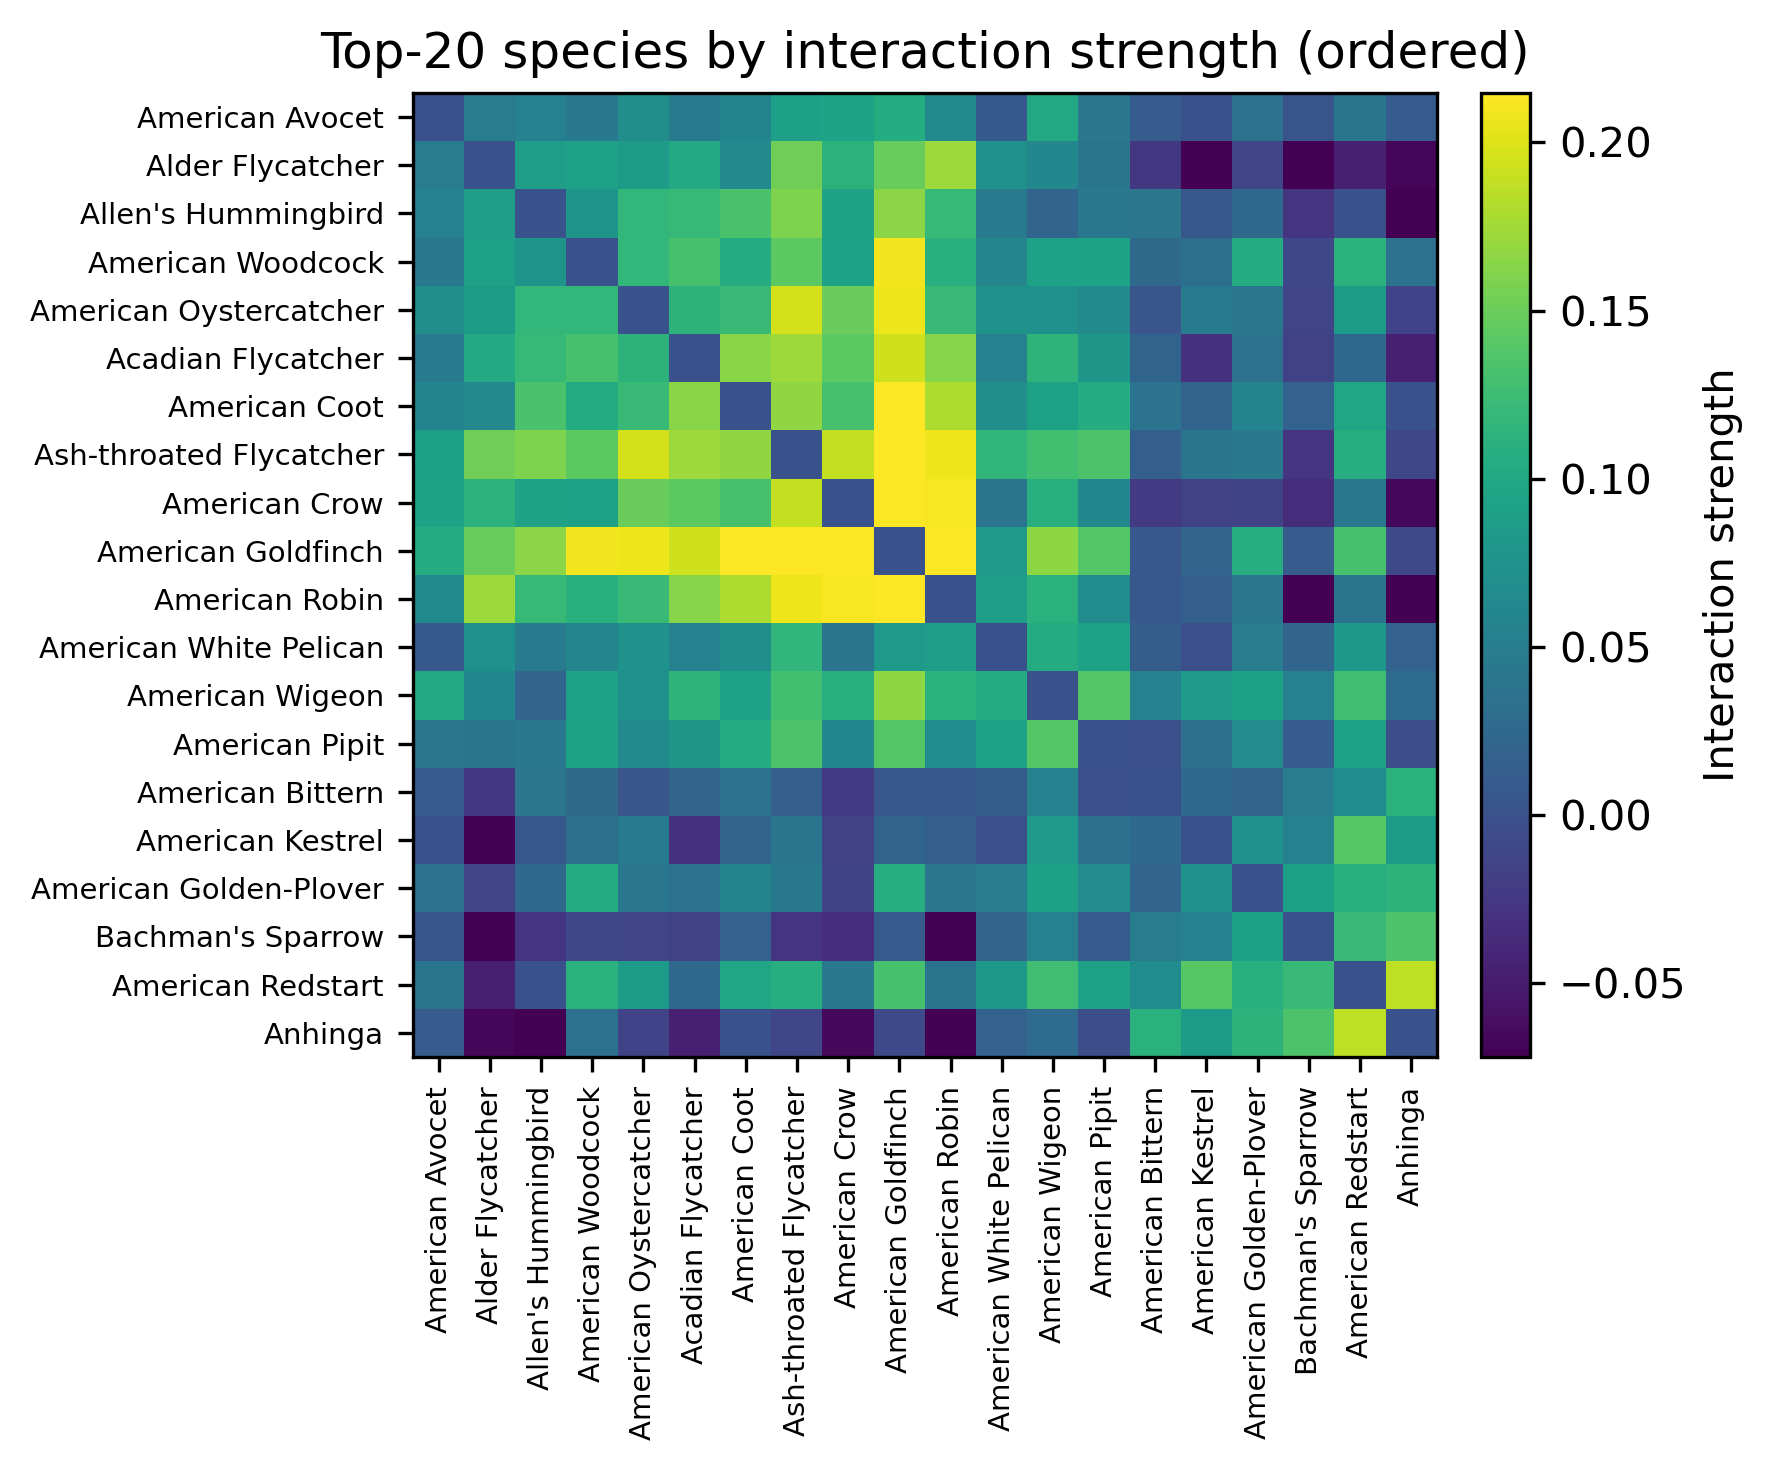

                    species  strength_mean_abs
0        American Goldfinch           0.130681
1   Ash-throated Flycatcher           0.115944
2            American Robin           0.106406
3             American Crow           0.092506
4             American Coot           0.091984
5        Acadian Flycatcher           0.088677
6           American Wigeon           0.087498
7    American Oystercatcher           0.085718
8         American Woodcock           0.084412
9         American Redstart           0.082466
10         Alder Flycatcher           0.076961
11      Allen's Hummingbird           0.070609
12           American Pipit           0.065586
13   American Golden-Plover           0.056428
14                  Anhinga           0.055514
15   American White Pelican           0.054552
16          American Avocet           0.046360
17        Bachman's Sparrow           0.042132
18         American Kestrel           0.039779
19         American Bittern           0.028186


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# --- helper: cluster order on similarity matrix ---
def cluster_order(R, method="average"):
    M = np.clip(R, -1, 1)
    np.fill_diagonal(M, 1.0)
    D = 1.0 - M
    np.fill_diagonal(D, 0.0)
    Z = linkage(squareform(D, checks=False), method=method)
    return leaves_list(Z)

# --- 1) per-species interaction strength (mean |off-diagonal|) ---
def species_strength(R, agg="mean_abs"):
    A = np.array(R, dtype=float).copy()
    np.fill_diagonal(A, 0.0)
    if agg == "mean_abs":
        s = np.nanmean(np.abs(A), axis=1)
    elif agg == "sum_abs":
        s = np.nansum(np.abs(A), axis=1)
    elif agg == "max_abs":
        s = np.nanmax(np.abs(A), axis=1)
    elif agg == "mean_pos":
        s = np.nanmean(np.clip(A, 0, None), axis=1)      # positive-only
    elif agg == "mean_signed":
        s = np.nanmean(A, axis=1)                        # signed mean
    else:
        raise ValueError("agg must be one of: mean_abs, sum_abs, max_abs, mean_pos, mean_signed")
    return s

# Inputs you already have:
# R : (S x S) species interaction/correlation matrix with unit diagonal
# E.index (or species_names) : list of species names length S
names = list(E.index.astype(str))  # or: names = species_names

# 2) pick the top-20 by strength
strength = species_strength(R, agg="mean_abs")
idx_top20 = np.argsort(strength)[::-1][:20]
species20 = [names[i] for i in idx_top20]

# 3) subset and recluster within the 20
R20 = R[np.ix_(idx_top20, idx_top20)]
order20 = cluster_order(R20, method="average")
R20_ord = R20[np.ix_(order20, order20)].copy()
names20_ord = [species20[i] for i in order20]

# 4) zero diagonal for display & set tight color limits
np.fill_diagonal(R20_ord, 0.0)
off = R20_ord[~np.eye(R20_ord.shape[0], dtype=bool)]
lo, hi = np.quantile(off, [0.02, 0.98])
if np.isclose(lo, hi):
    pad = 1e-3 if hi == 0 else 0.05*abs(hi)
    lo, hi = lo - pad, hi + pad

# 5) plot
fig, ax = plt.subplots(figsize=(6,5), dpi=300)
im = ax.imshow(R20_ord, vmin=float(lo), vmax=float(hi), interpolation="nearest", aspect="auto")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cbar.set_label("Interaction strength")

ax.set_title("Top-20 species by interaction strength (ordered)")
S = R20_ord.shape[0]
ax.set_xticks(range(S)); ax.set_yticks(range(S))
ax.set_xticklabels(names20_ord, rotation=90, fontsize=7)
ax.set_yticklabels(names20_ord, fontsize=7)

plt.tight_layout()
plt.show()

# Optional: table of top-20 with their strength values
top20_table = pd.DataFrame({
    "species": species20,
    "strength_mean_abs": strength[idx_top20]
}).sort_values("strength_mean_abs", ascending=False).reset_index(drop=True)
print(top20_table)


In [ ]:
##Top-20 by “signal” in a species×feature matrix (if you computed CF)
K = 20
signal = CF.abs().mean(axis=1).sort_values(ascending=False)  # average |ρ| across features
species20 = signal.head(K).index.tolist()


In [59]:
# if needed:
E.index = list(Y_df.columns.astype(str))


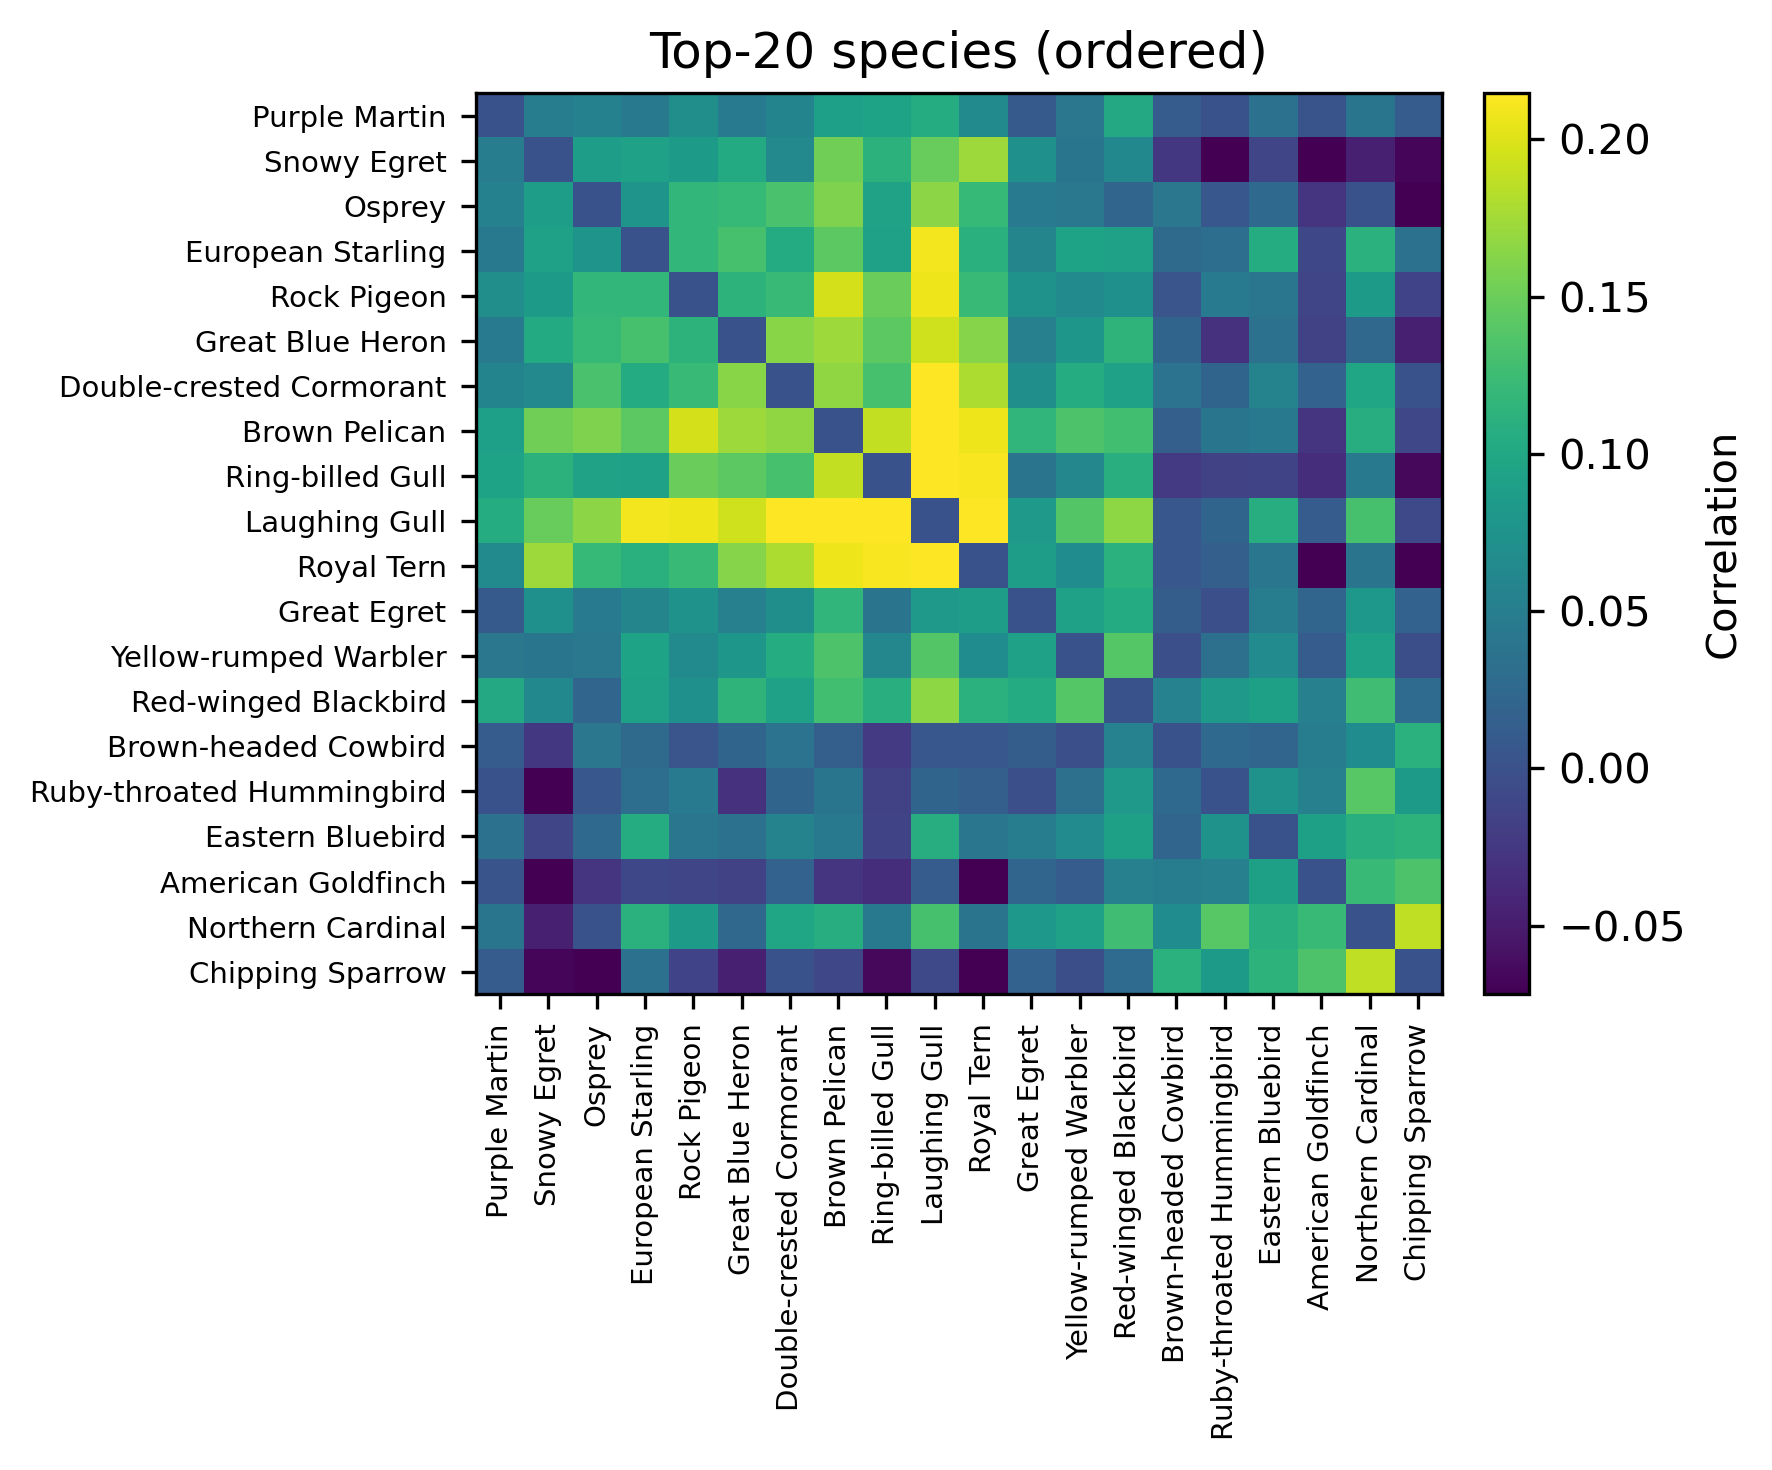

In [60]:
import numpy as np, matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# --- subset embedding to the 20 species ---
E20 = E.loc[species20].copy()             # rows = selected species
X = E20.to_numpy(float)
X = X - X.mean(axis=1, keepdims=True)     # center per species
R = np.corrcoef(X)                        # (20 x 20)
np.fill_diagonal(R, 1.0)

# --- cluster order (average linkage on 1 - r) ---
def cluster_order(R, method="average"):
    M = np.clip(R, -1, 1); np.fill_diagonal(M, 1.0)
    D = 1.0 - M;           np.fill_diagonal(D, 0.0)
    Z = linkage(squareform(D, checks=False), method=method)
    return leaves_list(Z)

order = cluster_order(R)
R_ord = R[np.ix_(order, order)].copy()
names_ord = [E20.index[i] for i in order]

# zero diagonal *for display only*
np.fill_diagonal(R_ord, 0.0)

# tight color limits
off = R_ord[~np.eye(R_ord.shape[0], dtype=bool)]
lo, hi = np.quantile(off, [0.02, 0.98])
if np.isclose(lo, hi):
    pad = 1e-3 if hi == 0 else 0.05*abs(hi); lo, hi = lo - pad, hi + pad

# --- plot ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
im = ax.imshow(R_ord, vmin=float(lo), vmax=float(hi), interpolation="nearest", aspect="auto")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cbar.set_label("Correlation")

ax.set_title("Top-20 species (ordered)")
S = R_ord.shape[0]
ax.set_xticks(range(S)); ax.set_yticks(range(S))
ax.set_xticklabels(names_ord, rotation=90, fontsize=7)
ax.set_yticklabels(names_ord, fontsize=7)

plt.tight_layout()
plt.show()


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from sklearn.metrics.pairwise import cosine_similarity

# ---------- Build interaction (species × species) ----------
def build_interaction(B_df, mode='corr', add_identity=True, eps=1e-6):
    """
    B_df: pandas DataFrame [S × D] (rows=species, cols=embedding dims)
    mode: 'factor' | 'corr' | 'cosine'
    returns: (R, label) where R is species×species similarity/correlation
    """
    B = B_df.to_numpy(dtype=np.float32)  # compact in memory
    S = B.shape[0]

    if mode == 'factor':
        # Σ = B Bᵀ (+ I), then convert to correlation
        Sigma = B @ B.T
        if add_identity:
            Sigma += np.eye(S, dtype=np.float32)
        d = np.sqrt(np.clip(np.diag(Sigma), eps, None))
        R = Sigma / np.outer(d, d)
        np.fill_diagonal(R, 1.0)
        label = 'Residual correlation (Σ = BBᵀ + I)'
    elif mode == 'corr':
        # Pearson correlation between rows (species)
        Bc = B - B.mean(axis=0, keepdims=True)  # column-center
        R = np.corrcoef(Bc)
        label = 'Row-wise Pearson correlation'
    elif mode == 'cosine':
        R = cosine_similarity(B)
        np.fill_diagonal(R, 1.0)
        label = 'Cosine similarity'
    else:
        raise ValueError('mode must be "factor", "corr", or "cosine"')

    return R, label

# ---------- Plot heatmap with zeroed diagonal & clustering ----------
def heatmap_species_matrix(M, species_names=None, title="Species interactions",
                           cluster=True, zero_diagonal=True, vmin=-1.0, vmax=1.0):
    M = np.asarray(M)
    assert M.ndim == 2 and M.shape[0] == M.shape[1], "M must be square"
    S = M.shape[0]

    # Cluster to reveal blocks
    order = np.arange(S)
    if cluster and S > 2:
        Mc = np.clip(M, -1, 1)
        np.fill_diagonal(Mc, 1.0)
        dist = 1.0 - Mc
        np.fill_diagonal(dist, 0.0)
        Z = linkage(squareform(dist, checks=False), method="average")
        order = leaves_list(Z)

    Ms = M[np.ix_(order, order)].copy()

    # Zero the diagonal AFTER ordering for visualization only
    if zero_diagonal:
        np.fill_diagonal(Ms, 0.0)

    names = [species_names[i] for i in order] if species_names is not None else None

    fig, ax = plt.subplots(figsize=(8, 7), dpi=150)
    im = ax.imshow(Ms, vmin=vmin, vmax=vmax, interpolation="nearest", aspect="auto")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Interaction strength")

    ax.set_title(title)
    if names and len(names) <= 60:
        ax.set_xticks(range(S)); ax.set_yticks(range(S))
        ax.set_xticklabels(names, rotation=90, fontsize=6)
        ax.set_yticklabels(names, fontsize=6)
    else:
        step = max(1, S // 30)
        ax.set_xticks(range(0, S, step)); ax.set_yticks(range(0, S, step))
        if names:
            ax.set_xticklabels([names[i] for i in range(0, S, step)], rotation=90, fontsize=6)
            ax.set_yticklabels([names[i] for i in range(0, S, step)], fontsize=6)

    plt.tight_layout()
    plt.show()

# ---------- List strongest pairs (diag ignored) ----------
def top_pairs(M, species_names=None, k=20):
    A = np.asarray(M).copy()
    np.fill_diagonal(A, 0.0)
    iu = np.triu_indices_from(A, k=1)
    vals = A[iu]
    idx = np.argsort(np.abs(vals))[::-1][:k]
    pairs = [(iu[0][i], iu[1][i], float(vals[i])) for i in idx]
    if species_names is not None:
        pairs = [(species_names[i], species_names[j], v) for i, j, v in pairs]
    return pairs



In [53]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, leaves_list, fcluster
from scipy.spatial.distance import squareform

# --- 1) Get an order from a similarity/correlation matrix R (S×S) ---
def order_from_similarity(R, method="average"):
    """
    R: species×species similarity (e.g., correlation or cosine), in [-1,1].
    Returns: order (np.array of indices), Z (linkage) for optional clustering.
    """
    M = np.asarray(R, dtype=float)
    M = np.clip(M, -1, 1)
    np.fill_diagonal(M, 1.0)
    # distance = 1 - similarity
    D = 1.0 - M
    np.fill_diagonal(D, 0.0)
    Z = linkage(squareform(D, checks=False), method=method)
    order = leaves_list(Z)
    return order, Z

# --- 2) Apply the order ---
def apply_order(R, names=None, order=None):
    """
    Reorders a square matrix and names using 'order'.
    """
    if order is None:
        order = np.arange(R.shape[0])
    R_ord = R[np.ix_(order, order)]
    names_ord = [names[i] for i in order] if names is not None else None
    return R_ord, names_ord

# --- 3) Optional: cut dendrogram into k clusters (labels aligned to 'order') ---
def cluster_labels(Z, k=None, height=None):
    """
    Either set k (number of clusters) or height (threshold).
    """
    if (k is None) == (height is None):
        raise ValueError("Set exactly one of k or height.")
    crit = ("maxclust" if k is not None else "distance")
    t = (k if k is not None else height)
    return fcluster(Z, t=t, criterion=crit)

# ===== Example usage =====
# Suppose you already have:
#   - R, names from earlier (species×species similarity)
# Or you computed R from your embedding / feature–label matrix.

order, Z = order_from_similarity(R, method="average")

# Reorder matrix & names
R_ord, names_ord = apply_order(R, names, order)

# (Optional) zero the diagonal for plotting ONLY
R_plot = R_ord.copy()
np.fill_diagonal(R_plot, 0.0)

# Save ordered outputs (nice for inspection)
pd.DataFrame(R_ord, index=names_ord, columns=names_ord).to_csv("species_interactions_ordered.csv")
pd.Series(names_ord, name="species_order").to_csv("species_order.txt", index=False)

# (Optional) get cluster IDs (aligned to original indices or to 'order')
k = 8  # choose your number of clusters
cluster_id = cluster_labels(Z, k=k)            # length = S, original index order
cluster_id_ord = cluster_id[order]             # aligned to 'names_ord'
pd.Series(cluster_id_ord, index=names_ord, name="cluster").to_csv("species_clusters.csv")


In [47]:
Y_df = count_predictions.iloc[:,2:]
Y_df

,Acadian Flycatcher,Alder Flycatcher,Allen's Hummingbird,American Avocet,American Bittern,American Coot,American Crow,American Golden-Plover,American Goldfinch,American Kestrel,...,Yellow Warbler,Yellow-bellied Flycatcher,Yellow-bellied Sapsucker,Yellow-billed Cuckoo,Yellow-breasted Chat,Yellow-crowned Night Heron,Yellow-headed Blackbird,Yellow-rumped Warbler,Yellow-throated Vireo,Yellow-throated Warbler
0,0,0,0,0,0,0,45,0,2,0,...,0,0,0,0,0,0,0,9,0,0
1,0,0,0,0,0,4,24,0,0,1,...,0,0,0,0,0,0,0,215,0,0
2,0,0,0,0,0,0,64,0,1,0,...,0,0,0,0,0,0,0,14,0,0
3,0,0,0,0,0,1,25,0,0,1,...,0,0,0,0,0,0,0,185,0,0
4,0,0,0,0,0,0,48,0,2,0,...,0,0,0,0,0,0,0,10,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5861,0,0,0,0,0,0,13,0,1,0,...,0,0,0,0,0,0,0,58,0,0
5862,0,0,0,0,0,0,13,0,1,0,...,0,0,0,0,0,0,0,57,0,0
5863,0,0,0,0,0,0,13,0,1,0,...,0,0,0,0,0,0,0,58,0,0
5864,0,0,0,0,0,0,13,0,1,0,...,0,0,0,0,0,0,0,58,0,0


In [50]:
X_df = pd.read_csv("pred_pland_elev_poc_chl_t_trangeintHigh_3year_mp_marshmigration.csv")
X_df = X_df.drop(columns=["id"])
X_df

,agriculture,forest,fresh_woody_wetland,grassland,pasture,shrub,urban,water,fresh_marsh,barren,...,eastness_median,eastness_sd,slopeness_median,slopeness_sd,t_mean,trange_mean,elevation_median,elevation_sd,poc_mean,chl_mean
0,0.000126,0.830732,0.098792,0.005034,0.026303,0.038132,0.000126,0.000252,0.000000,0.000000,...,-0.133841,0.336319,0.988993,0.196292,0.198404,0.981755,117.156609,6.585327,0.621959,0.828482
1,0.000000,0.483696,0.143648,0.067229,0.145285,0.132066,0.000000,0.004532,0.001259,0.000000,...,0.087380,0.286207,0.748420,0.189879,0.197177,0.984153,129.015381,3.131303,0.675814,0.800176
2,0.000000,0.673431,0.096042,0.021931,0.036804,0.144190,0.001512,0.001765,0.000504,0.000126,...,0.073307,0.310156,0.817156,0.193318,0.203474,0.982097,114.252029,7.764437,0.577217,0.807298
3,0.000126,0.551833,0.140320,0.046857,0.116639,0.123693,0.000126,0.004535,0.003779,0.000000,...,-0.088071,0.333790,0.924225,0.199978,0.201682,0.980540,110.275711,8.936956,0.660895,0.793092
4,0.000000,0.596265,0.091219,0.080621,0.101691,0.095887,0.000252,0.006561,0.009463,0.000000,...,0.224000,0.290197,0.902748,0.251762,0.194370,0.984926,108.423260,8.634862,0.700971,0.787501
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5861,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.636364,0.000000,0.000000,...,-0.032045,0.099685,0.418185,0.090959,0.521233,0.518986,-116.758834,3.293083,0.769189,0.580295
5862,0.000000,0.000000,0.008128,0.000000,0.000000,0.000000,0.007964,0.030846,0.000000,0.000000,...,0.035204,0.124248,0.511171,0.104689,0.519517,0.525384,-103.504320,3.975993,0.554383,0.204792
5863,0.000000,0.462562,0.000048,0.009072,0.000000,0.037675,0.049529,0.000072,0.077718,0.002268,...,-0.023815,0.070257,0.441907,0.092879,0.525999,0.541018,-90.167969,2.146006,0.427358,0.341148
5864,0.000000,0.000000,0.030859,0.000000,0.000000,0.000000,0.007475,0.195509,0.000000,0.000000,...,0.009438,0.107838,0.369798,0.082318,0.534257,0.508956,-114.107046,2.040338,0.612941,0.410391


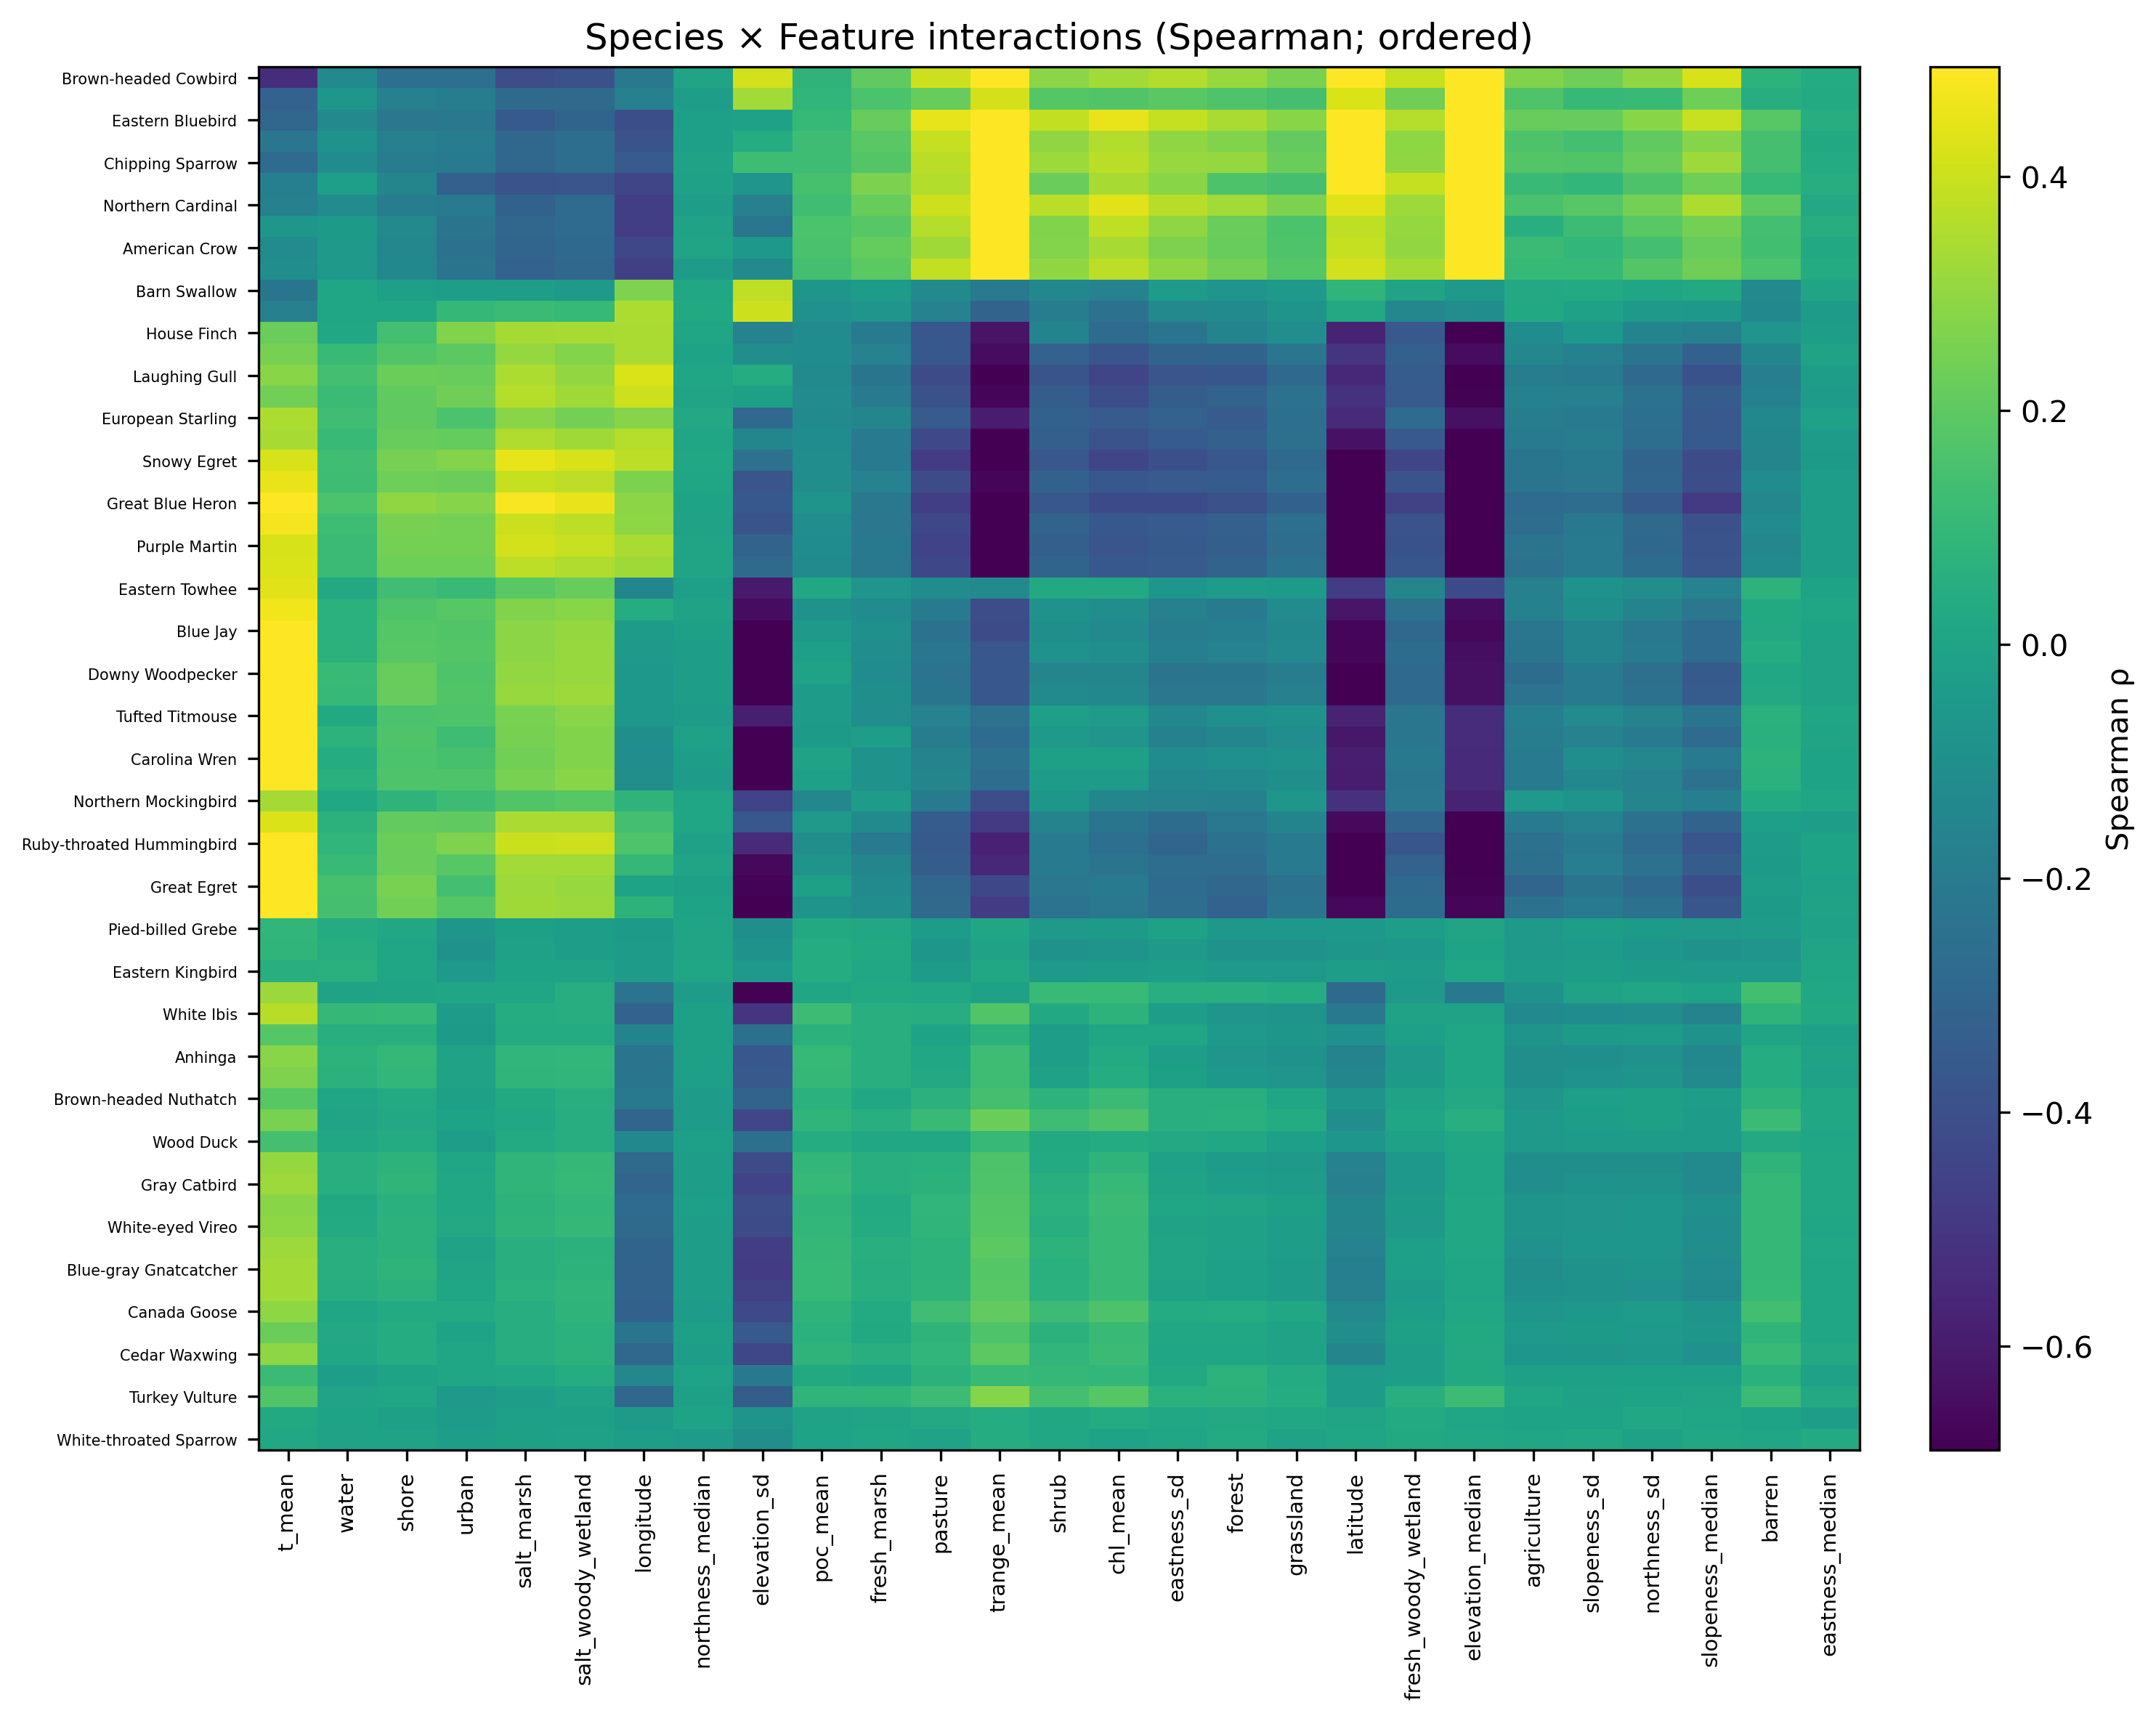

Saved PDF: ./species_by_feature_spearman_ordered.pdf
Saved ordered matrix: ./species_by_feature_spearman_ordered.csv


In [52]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from scipy.stats import rankdata

# --------------------------
# CONFIG
# --------------------------
out_dir = "."  # change to exp_dir if you like
pdf_name = "species_by_feature_spearman_ordered.pdf"
csv_name = "species_by_feature_spearman_ordered.csv"
min_nonzero_per_species = 10   # filter very-rare species; set 0 to keep all

# --------------------------
# 1) Pick the 28 features
# --------------------------
# Drop id-like columns; keep numeric; drop zero-variance
id_like = {"id", "ID", "grid_id", "cell_id", "month", "year"}
feature_cols = [c for c in X_df.columns
                if c not in id_like and np.issubdtype(X_df[c].dtype, np.number)]
# (Optional) ensure exactly 28 features if that's your design:
# feature_cols = feature_cols[:28]
# Drop zero-variance features
feature_cols = [c for c in feature_cols if X_df[c].nunique(dropna=True) > 1]

X_used = X_df[feature_cols].copy()

# --------------------------
# 2) Line up species columns
# --------------------------
species_cols = list(Y_df.columns.astype(str))

# Filter species with too few non-zeros to avoid undefined Spearman
if min_nonzero_per_species > 0:
    nz = (Y_df.values != 0).sum(axis=0)
    keep_mask = nz >= min_nonzero_per_species
    # If Y_df is DataFrame, match mask to columns order
    species_cols = [s for s, k in zip(species_cols, keep_mask) if k]
    if len(species_cols) == 0:
        raise ValueError("All species filtered out; lower min_nonzero_per_species.")
Y_used = Y_df[species_cols].copy()

# Sanity checks
assert X_used.shape[0] == Y_used.shape[0], "X_df and Y_df must have the same number of rows."
assert X_used.shape[1] > 0 and Y_used.shape[1] > 0, "Need at least 1 feature and 1 species."

# Drop rows that have NaNs in either table (rare but safer)
mask = ~(X_used.isna().any(axis=1) | Y_used.isna().any(axis=1))
if not mask.all():
    X_used = X_used.loc[mask]
    Y_used = Y_used.loc[mask]

# --------------------------
# 3) Spearman (species × feature)
# --------------------------
def spearman_species_feature(X: np.ndarray, Y: np.ndarray) -> np.ndarray:
    """
    X: (N, F) features
    Y: (N, S) species counts/preds
    Returns: (S, F) Spearman ρ (Pearson on column ranks)
    """
    Xr = np.apply_along_axis(rankdata, 0, X)  # (N, F)
    Yr = np.apply_along_axis(rankdata, 0, Y)  # (N, S)
    # z-score columns to compute Pearson on ranks
    Xr = (Xr - Xr.mean(axis=0)) / (Xr.std(axis=0) + 1e-12)
    Yr = (Yr - Yr.mean(axis=0)) / (Yr.std(axis=0) + 1e-12)
    return (Yr.T @ Xr) / (X.shape[0] - 1)

X = X_used.to_numpy(float)                 # (N, F)
Y = Y_used.to_numpy(float)                 # (N, S)
rho = spearman_species_feature(X, Y)       # (S, F)

CF = pd.DataFrame(rho, index=Y_used.columns, columns=X_used.columns)

# --------------------------
# 4) Cluster-order rows & cols
# --------------------------
def order_from_profiles(M: np.ndarray, rows=True, method="average"):
    """Cluster rows (rows=True) or columns (rows=False) by correlation of profiles."""
    X = M if rows else M.T
    Xc = X - X.mean(axis=1, keepdims=True)
    R = np.corrcoef(Xc)
    np.fill_diagonal(R, 1.0)
    D = 1.0 - np.clip(R, -1, 1)
    np.fill_diagonal(D, 0.0)
    Z = linkage(squareform(D, checks=False), method=method)
    return leaves_list(Z)

row_order = order_from_profiles(CF.values, rows=True)    # species
col_order = order_from_profiles(CF.values, rows=False)   # features
CF_ord = CF.iloc[row_order, :].iloc[:, col_order]

# --------------------------
# 5) Plot & save PDF
# --------------------------
vals = CF_ord.to_numpy().ravel()
lo, hi = np.nanquantile(vals, [0.02, 0.98])
if np.isclose(lo, hi):
    pad = 1e-3 if hi == 0 else 0.05 * abs(hi)
    lo, hi = lo - pad, hi + pad

fig, ax = plt.subplots(figsize=(10, 8), dpi=300)
im = ax.imshow(CF_ord, vmin=float(lo), vmax=float(hi),
               aspect="auto", interpolation="nearest")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Spearman ρ")

ax.set_title("Species × Feature interactions (Spearman; ordered)")

S, F = CF_ord.shape
step_r = max(1, S // 30)    # show ~30 labels
step_c = max(1, F // 28)

ax.set_yticks(range(0, S, step_r))
ax.set_xticks(range(0, F, step_c))
ax.set_yticklabels([CF_ord.index[i] for i in range(0, S, step_r)], fontsize=5)
ax.set_xticklabels([CF_ord.columns[j] for j in range(0, F, step_c)], rotation=90, fontsize=7)

plt.tight_layout()
os.makedirs(out_dir, exist_ok=True)
pdf_path = os.path.join(out_dir, pdf_name)
csv_path = os.path.join(out_dir, csv_name)
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()

CF_ord.to_csv(csv_path)
print(f"Saved PDF: {pdf_path}")
print(f"Saved ordered matrix: {csv_path}")

# --------------------------
# (Optional) quick summary: top-k features per species
# --------------------------
def topk_per_species(CF_df, k=3):
    out = {}
    for sp, row in CF_df.iterrows():
        pos = row.nlargest(k)
        neg = row.nsmallest(k)
        out[sp] = {
            "top_positive": list(zip(pos.index.tolist(), pos.values.round(3))),
            "top_negative": list(zip(neg.index.tolist(), neg.values.round(3)))
        }
    return out

# Example:
# summaries = topk_per_species(CF_ord, k=3)
# summaries["American Kestrel"]
